In [1]:
import pandas as pd 
df = pd.read_csv("/Users/omi/anomaly-detection/data/credit_card_fraud.csv")
df.head()

,Transaction Date and Time,Transaction Amount,Cardholder Name,Card Number (Hashed or Encrypted),Merchant Name,Merchant Category Code (MCC),Transaction Location (City or ZIP Code),Transaction Currency,Card Type,Card Expiration Date,CVV Code (Hashed or Encrypted),Transaction Response Code,Transaction ID,Fraud Flag or Label,Previous Transactions,Transaction Source,IP Address,Device Information,User Account Information,Transaction Notes
0,2022-09-24 13:54:27,285.88,Shray Soman,daca51bffe0fc4eaaa7c430917f94b75fd893712492254...,"Rajagopalan, Ghose and Kant",3590,Khammam,INR,MasterCard,04/29,01299ac65733b5a3d774265fbfe8396b8611e5e3321855...,5,b7f69cbc-a03d-41f8-adca-75920b0242c3,1,NaN,Online,18.106.240.6,Tablet,NaN,Consequatur corporis minima ad vero deserunt n...
1,2020-07-24 11:20:13,1777.32,Lakshit Bakshi,d5366dd9be3a0266c0252baceaa6332210ed4dbd0ef252...,Sule PLC,7277,Vasai-Virar,EUR,American Express,03/26,ad8fa913d25b3970c6efa8ca504da8ba670ce2a9cf012d...,12,ad53cc8e-8412-422e-8cad-4176daac8387,1,NaN,Online,212.48.185.128,Mobile,jloyal,Dolore repellendus odio deleniti. Eaque quibus...
2,2023-03-18 01:05:36,3939.01,Riya Bobal,4737a6384aa1c3c31f7768b86633d6a8401dd6ab4a8ff1...,Badal PLC,9297,Nangloi Jat,USD,Visa,11/29,eb3be230bbd2844b1f5d8f2e4fab9ffba8ab22cfeeb69c...,5,f09cecd6-0d74-4551-8089-a31d64e6b9c5,1,3 or more,In-Person,17.190.112.46,Mobile,NaN,Unde beatae perspiciatis sapiente. Voluptates ...
3,2021-01-07 21:53:04,376.44,Mohanlal Balakrishnan,4721806eed8f2663bb597ff13e79a294de318358fbb54b...,Konda-Sodhi,5686,Ramagundam,USD,Visa,09/25,891d46993a36d78392247c642138cede01d9841daab1d9...,5,b208ae0b-4c4f-428f-b6b9-5360b288b947,0,2,In-Person,153.136.24.104,Tablet,NaN,Cupiditate repellendus necessitatibus quo occa...
4,2021-12-16 06:22:24,1687.33,Mannat Rout,9deacc3a9efd6e382826d400620aca5f23ed94327578e5...,Dua Ltd,2940,Adoni,INR,MasterCard,03/31,48a1a756f2d83f1dc57bbf14052b70a6f40d0fceed6662...,5,6b4e4e43-5b73-4906-9973-299a1b2a5e71,1,2,Online,196.153.28.131,Desktop,NaN,Molestias assumenda consectetur itaque veritat...


In [2]:
df.shape

(8000, 20)

In [3]:
df.columns

Index(['Transaction Date and Time', 'Transaction Amount', 'Cardholder Name',
       'Card Number (Hashed or Encrypted)', 'Merchant Name',
       'Merchant Category Code (MCC)',
       'Transaction Location (City or ZIP Code)', 'Transaction Currency',
       'Card Type', 'Card Expiration Date', 'CVV Code (Hashed or Encrypted)',
       'Transaction Response Code', 'Transaction ID', 'Fraud Flag or Label',
       'Previous Transactions', 'Transaction Source', 'IP Address',
       'Device Information', 'User Account Information', 'Transaction Notes'],
      dtype='object')

In [4]:
df["Fraud Flag or Label"].value_counts()

Fraud Flag or Label
0    4011
1    3989
Name: count, dtype: int64

In [8]:
X = df.drop("Fraud Flag or Label", axis=1)
y = df["Fraud Flag or Label"]

In [9]:
X = X.select_dtypes(include=["number"])
X.head()

,Transaction Amount,Merchant Category Code (MCC),Transaction Response Code
0,285.88,3590,5
1,1777.32,7277,12
2,3939.01,9297,5
3,376.44,5686,5
4,1687.33,2940,5


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.5,
    random_state=42
)

iso_model.fit(X_scaled)

IsolationForest(contamination=0.5, random_state=42)

In [12]:
iso_preds = iso_model.predict(X_scaled)
iso_preds[:10]

array([-1,  1, -1,  1,  1, -1,  1,  1, -1, -1])

In [13]:
import numpy as np

iso_preds = np.where(iso_preds == -1, 1, 0)

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y, iso_preds))
print(classification_report(y, iso_preds))

[[2041 1970]
 [1959 2030]]
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      4011
           1       0.51      0.51      0.51      3989

    accuracy                           0.51      8000
   macro avg       0.51      0.51      0.51      8000
weighted avg       0.51      0.51      0.51      8000



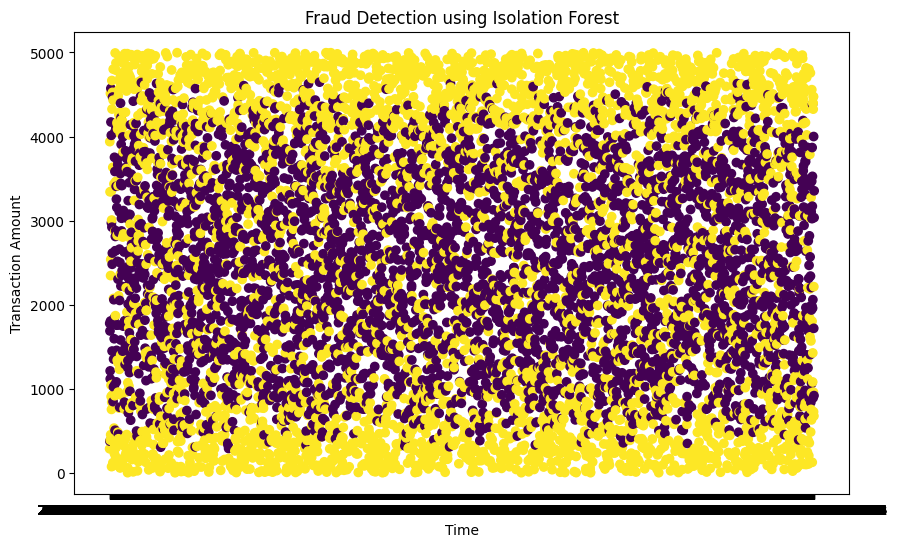

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df["Transaction Date and Time"], df["Transaction Amount"], c=iso_preds)
plt.xlabel("Time")
plt.ylabel("Transaction Amount")
plt.title("Fraud Detection using Isolation Forest")
plt.show()

In [16]:
from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.5
)

lof_preds = lof_model.fit_predict(X_scaled)

In [17]:
lof_preds = np.where(lof_preds == -1, 1, 0)

In [18]:
print(confusion_matrix(y, lof_preds))
print(classification_report(y, lof_preds))

[[1995 2016]
 [2005 1984]]
              precision    recall  f1-score   support

           0       0.50      0.50      0.50      4011
           1       0.50      0.50      0.50      3989

    accuracy                           0.50      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       0.50      0.50      0.50      8000



In [19]:
models = ["Isolation Forest", "Local Outlier Factor"]

fraud_detected = [
    iso_preds.sum(),
    lof_preds.sum()
]

comparison = pd.DataFrame({
    "Model": models,
    "Fraud Predictions": fraud_detected
})

comparison

,Model,Fraud Predictions
0,Isolation Forest,4000
1,Local Outlier Factor,4000


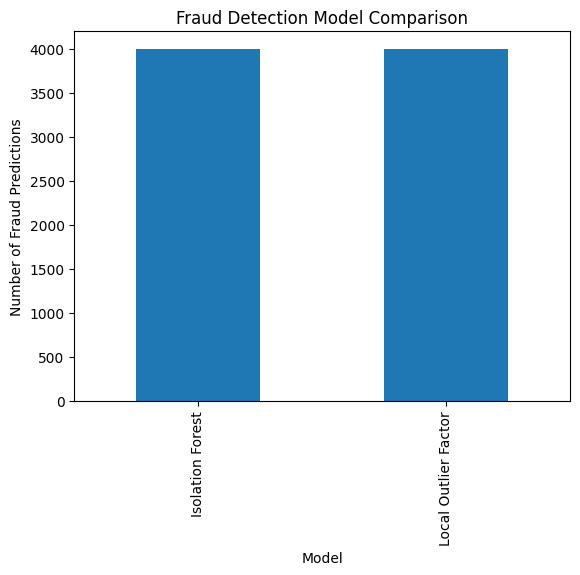

In [20]:
comparison.plot(
    x="Model",
    y="Fraud Predictions",
    kind="bar",
    legend=False
)

plt.title("Fraud Detection Model Comparison")
plt.ylabel("Number of Fraud Predictions")
plt.show()

In [21]:
df["High_Amount_Flag"] = (df["Transaction Amount"] > df["Transaction Amount"].median()).astype(int)

In [22]:
df[["Transaction Amount","High_Amount_Flag"]].head()

,Transaction Amount,High_Amount_Flag
0,285.88,0
1,1777.32,0
2,3939.01,1
3,376.44,0
4,1687.33,0


In [25]:
df["Previous Transactions"] = df["Previous Transactions"].replace("3 or more", 3)

In [26]:
df["Previous Transactions"] = pd.to_numeric(df["Previous Transactions"], errors="coerce")

In [27]:
df["Previous Transactions"] = df["Previous Transactions"].fillna(0)

In [28]:
df["High_Transaction_Count"] = (
    df["Previous Transactions"] > df["Previous Transactions"].median()
).astype(int)

In [29]:
df[["Previous Transactions", "High_Transaction_Count"]].head()

,Previous Transactions,High_Transaction_Count
0,0.0,0
1,0.0,0
2,3.0,1
3,2.0,1
4,2.0,1


In [30]:
df["Foreign_Currency_Flag"] = (df["Transaction Currency"] != "USD").astype(int)

In [31]:
df[["Transaction Currency","Foreign_Currency_Flag"]].head()

,Transaction Currency,Foreign_Currency_Flag
0,INR,1
1,EUR,1
2,USD,0
3,USD,0
4,INR,1


In [32]:
X = df.drop("Fraud Flag or Label", axis=1)
y = df["Fraud Flag or Label"]

X = X.select_dtypes(include=["number"])

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
iso_model = IsolationForest(contamination=0.5, random_state=42)
iso_model.fit(X_scaled)

iso_preds = iso_model.predict(X_scaled)
iso_preds = np.where(iso_preds == -1, 1, 0)

In [37]:
print(confusion_matrix(y, iso_preds))
print(classification_report(y, iso_preds))

[[2041 1970]
 [1959 2030]]
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      4011
           1       0.51      0.51      0.51      3989

    accuracy                           0.51      8000
   macro avg       0.51      0.51      0.51      8000
weighted avg       0.51      0.51      0.51      8000



In [38]:
df["Anomaly_Score"] = iso_model.decision_function(X_scaled)

In [39]:
df[["Transaction Amount","Fraud Flag or Label","Anomaly_Score"]].head()

,Transaction Amount,Fraud Flag or Label,Anomaly_Score
0,285.88,1,0.014563
1,1777.32,1,0.015395
2,3939.01,1,-0.025557
3,376.44,0,-0.009794
4,1687.33,1,0.036106


In [42]:
df_sorted = df.sort_values("Anomaly_Score")
df_sorted.head(10)

,Transaction Date and Time,Transaction Amount,Cardholder Name,Card Number (Hashed or Encrypted),Merchant Name,Merchant Category Code (MCC),Transaction Location (City or ZIP Code),Transaction Currency,Card Type,Card Expiration Date,...,Previous Transactions,Transaction Source,IP Address,Device Information,User Account Information,Transaction Notes,High_Amount_Flag,High_Transaction_Count,Foreign_Currency_Flag,Anomaly_Score
2314,2022-05-31 02:05:53,87.48,Jiya Loyal,04840e9385bbb0ff15476b9f15118d79990b3ee8539543...,Subramaniam LLC,1058,Chandigarh,USD,American Express,12/32,...,3.0,In-Person,49.170.140.54,Desktop,venkateshkrish,Incidunt ullam porro. Quam eligendi velit labo...,0,1,0,-0.083596
2456,2022-06-17 17:33:53,4996.70,Emir Dara,36b023528f236b3e3fb465e57a5061808ab557278f7cf0...,"Sodhi, Manda and Yohannan",1049,Raurkela Industrial Township,USD,MasterCard,07/26,...,0.0,Online,120.102.30.106,Tablet,santaayush,Quibusdam voluptates nobis aliquam. Placeat ne...,1,0,0,-0.078274
6223,2020-08-01 11:30:53,4909.97,Taimur Raman,19691415260916130aa0081738ab4f321d24e405cab448...,Virk Inc,9479,Kota,USD,Visa,07/32,...,0.0,Online,223.242.71.172,Tablet,NaN,Sequi modi eveniet non velit repudiandae imped...,1,0,0,-0.077708
7143,2023-06-25 06:20:04,4939.98,Anya Sawhney,2fc3010b2998f61d5ad2570b0704275724eca887624d08...,Bala-Mammen,1301,Tiruchirappalli,USD,American Express,09/29,...,3.0,Online,22.186.127.121,Mobile,NaN,Ea perspiciatis fugiat cumque fugit. Blanditii...,1,1,0,-0.076525
4209,2022-12-05 08:28:41,4914.77,Devansh Ghose,ced6d195564f3f18ebbacf371b8a0189583f50f18aa1c0...,Badami-Varty,1293,Mau,USD,Visa,03/26,...,2.0,In-Person,16.52.251.213,Mobile,dharmajansethi,Totam quae quos nostrum non. Maxime dolor cum....,1,1,0,-0.076313
6711,2020-09-22 16:43:53,255.83,Jayant Iyer,ad35eb657e942a978845e376a7873277a5ad36090a83dc...,"Guha, Ramaswamy and Dhar",1110,Bhimavaram,USD,American Express,11/29,...,3.0,In-Person,180.227.209.156,Desktop,bhaminichoudhury,Nesciunt minima neque minus facilis. Harum ten...,0,1,0,-0.075843
151,2022-11-30 06:05:45,4872.77,Inaaya Tandon,531ee50bff4518de1157f3cf0d01159477fb49ae694578...,"Devi, Sastry and Wable",9460,Haridwar,USD,Visa,02/32,...,0.0,In-Person,193.68.238.123,Desktop,NaN,Ut veniam rerum reiciendis quod repellat. Ad l...,1,0,0,-0.075632
3404,2020-01-24 14:23:41,4726.15,Indranil Dube,fe1c8c32bf4833e4d00beabdfde63ff4bcfaee76f45bbc...,Doctor-Ramachandran,1080,Suryapet,USD,MasterCard,05/33,...,0.0,Online,164.64.168.193,Desktop,samarthray,Quam ab tempore natus error. Sed fugiat except...,1,0,0,-0.075083
1018,2021-02-28 14:12:39,4837.98,Priyansh Dyal,1229cdcaabd4f4b33d908685a422a81504301588e36a83...,"Gera, Karan and Warrior",1109,Kishanganj,USD,Visa,07/32,...,3.0,In-Person,25.110.207.87,Desktop,NaN,Tempore magnam ad optio. Minima ratione natus ...,1,1,0,-0.075006
3158,2021-08-09 02:27:46,193.82,Amani Rattan,da3ff49b68e5d62004977b53de66ef9bb23975a7cb50ea...,Soman Inc,9776,Chandrapur,USD,MasterCard,08/30,...,0.0,Online,213.107.94.42,Tablet,NaN,Praesentium assumenda eos hic. Quaerat blandit...,0,0,0,-0.073409


In [43]:
suspicious = df_sorted.head(100)

suspicious["Fraud Flag or Label"].value_counts()

Fraud Flag or Label
0    62
1    38
Name: count, dtype: int64

In [44]:
df["Risk_Level"] = pd.qcut(
    df["Anomaly_Score"],
    q=4,
    labels=["High Risk","Medium Risk","Low Risk","Very Low Risk"]
)

In [45]:
df["Risk_Level"].value_counts()

Risk_Level
High Risk        2000
Medium Risk      2000
Low Risk         2000
Very Low Risk    2000
Name: count, dtype: int64

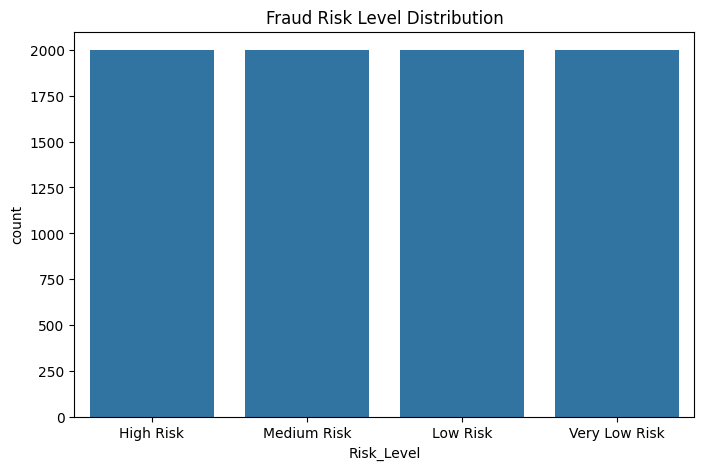

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Risk_Level")

plt.title("Fraud Risk Level Distribution")
plt.show()

In [47]:
alerts = df_sorted.head(20)[[
    "Transaction Date and Time",
    "Transaction Amount",
    "Merchant Name",
    "Fraud Flag or Label",
    "Anomaly_Score"
]]

alerts

,Transaction Date and Time,Transaction Amount,Merchant Name,Fraud Flag or Label,Anomaly_Score
2314,2022-05-31 02:05:53,87.48,Subramaniam LLC,0,-0.083596
2456,2022-06-17 17:33:53,4996.70,"Sodhi, Manda and Yohannan",1,-0.078274
6223,2020-08-01 11:30:53,4909.97,Virk Inc,0,-0.077708
7143,2023-06-25 06:20:04,4939.98,Bala-Mammen,0,-0.076525
4209,2022-12-05 08:28:41,4914.77,Badami-Varty,0,-0.076313
6711,2020-09-22 16:43:53,255.83,"Guha, Ramaswamy and Dhar",0,-0.075843
151,2022-11-30 06:05:45,4872.77,"Devi, Sastry and Wable",0,-0.075632
3404,2020-01-24 14:23:41,4726.15,Doctor-Ramachandran,0,-0.075083
1018,2021-02-28 14:12:39,4837.98,"Gera, Karan and Warrior",0,-0.075006
3158,2021-08-09 02:27:46,193.82,Soman Inc,1,-0.073409
